In [2]:
import torch
import torch.nn as nn
import pytorch_lightning as pl
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mne
from pathlib import Path
from scipy.signal import butter, sosfiltfilt
from sklearn.metrics import r2_score
from tqdm import tqdm

In [7]:
class CatPool1d(nn.Module):
    def __init__(self, kernel_size, channels):
        super().__init__()
        self.avg = nn.AvgPool1d(kernel_size)
        self.max = nn.MaxPool1d(kernel_size)
        self.proj = nn.Conv1d(channels * 2, channels, 1, bias=False)

    def forward(self, x):
        return self.proj(torch.cat([self.avg(x), self.max(x)], dim=1))


class CatAdaptivePool1d(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.avg = nn.AdaptiveAvgPool1d(1)
        self.max = nn.AdaptiveMaxPool1d(1)
        self.proj = nn.Conv1d(channels * 2, channels, 1, bias=False)

    def forward(self, x):
        return self.proj(torch.cat([self.avg(x), self.max(x)], dim=1))


class EEGTemporalCNN(nn.Module):
    def __init__(self, n_channels, n_outputs, dropout=0.2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv1d(n_channels, 64, 128, padding=64, bias=False),
            nn.BatchNorm1d(64), nn.GELU(), CatPool1d(4, 64), nn.Dropout(dropout),
            nn.Conv1d(64, 128, 16, padding=8, bias=False),
            nn.BatchNorm1d(128), nn.GELU(), CatPool1d(4, 128), nn.Dropout(dropout),
            nn.Conv1d(128, 256, 8, padding=4, bias=False),
            nn.BatchNorm1d(256), nn.GELU(),
            CatAdaptivePool1d(256), nn.Flatten(),
            nn.Linear(256, 128), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(128, n_outputs),
        )

    def forward(self, x):
        return self.net(x)


class EEGRegressor(pl.LightningModule):
    def __init__(self, n_channels, n_outputs, lr=3e-4):
        super().__init__()
        self.save_hyperparameters()
        self.net = EEGTemporalCNN(n_channels, n_outputs)
        self.loss = nn.MSELoss()

    def forward(self, x):
        return self.net(x)

In [8]:
CKPT_PATH  = "model_data/cv_results_stratified/checkpoints_1/fold8-topepoch=15-val_r2_mean=0.3230.ckpt"
DATA_DIR   = "model_data/non_ica_19_channels_thresh"
PCA_PATH   = "model_data/matched_pca_vectors.parquet"
SFREQ      = 256        
SEG_LEN    = 2560 
N_SEG      = 1            
N_WINDOWS  = 100     
N_CH       = 19
DEVICE     = "mps"      

model = EEGRegressor.load_from_checkpoint(CKPT_PATH, map_location=DEVICE)
model.eval()
print("Loaded v4:", sum(p.numel() for p in model.parameters()), "params")

Loaded v4: 754817 params


In [9]:
pca_vals_raw = pd.read_parquet(PCA_PATH)
pca_vals = pd.DataFrame(
    np.stack(pca_vals_raw["vector"].to_numpy()),
    index=pca_vals_raw["subject"].astype(str),
)

all_subjects = np.array(sorted(
    set(pca_vals.index) & {p.stem for p in Path(DATA_DIR).glob("*.parquet")}
))
shuffled   = np.random.default_rng(42).permutation(all_subjects)
n_train    = int(0.8 * len(shuffled))
test_subjects = shuffled[n_train:]
print(f"{len(test_subjects)} test subjects")

313 test subjects


In [10]:
# Compute PC-1 normalisation stats from train split only
train_subjects = shuffled[:n_train]
train_raw = np.stack([pca_vals.loc[s].to_numpy(dtype=np.float32)[0]
                      for s in train_subjects])
target_mean = train_raw.mean().astype(np.float32)
target_std  = (train_raw.std() + 1e-8).astype(np.float32)

def norm_target(val):
    return (val - target_mean) / target_std

# Load test subjects into memory: {subject_id: np.array (n_seg, 8, 2560)}
paths = {p.stem: p for p in Path(DATA_DIR).glob("*.parquet")}
test_cache   = {}
test_targets = {}

for s in tqdm(test_subjects, desc="Loading test subjects"):
    df = (pd.read_parquet(paths[s], columns=["channel_name", "segment", "segment_index"])
            .sort_values(["segment_index", "channel_name"]))
    n_seg = df["segment_index"].nunique()
    n_ch  = df["channel_name"].nunique()
    arr   = np.stack([np.pad(np.asarray(a, dtype=np.float32)[:SEG_LEN],
                             (0, max(0, SEG_LEN - len(a))), mode="reflect")
                      for a in df["segment"]])
    test_cache[s]   = arr.reshape(n_seg, n_ch, SEG_LEN)   # (n_seg, 8, 2560)
    test_targets[s] = norm_target(float(pca_vals.loc[s, 0]))

CH_NAMES = sorted(df["channel_name"].unique())  # ['C3','C4','F3','F4','O1','O2','P3','P4']
print("Channel order:", CH_NAMES)

Loading test subjects: 100%|██████████| 313/313 [00:15<00:00, 20.34it/s]

Channel order: ['C3', 'C4', 'Cz', 'F3', 'F4', 'F7', 'F8', 'Fp1', 'Fp2', 'Fz', 'O1', 'O2', 'P3', 'P4', 'P7', 'P8', 'Pz', 'T7', 'T8']


In [38]:
def run_inference(cache, targets, transform=None, n_windows=N_WINDOWS, seed=0):
    """Return per-subject-averaged R² over test set.
    transform: optional callable (arr: np.ndarray (8, L)) -> np.ndarray (8, L)
               applied to each window BEFORE model forward pass.
    """
    rng = np.random.default_rng(seed)
    all_preds, all_tgts = [], []

    with torch.no_grad():
        for s, arr in cache.items():          # arr: (n_seg, 8, 2560)
            n_avail = len(arr)
            preds_subj = []
            for _ in range(n_windows):
                start = rng.integers(0, max(1, n_avail - N_SEG + 1))
                window = arr[start:start + N_SEG]          # (N_SEG, 8, 2560)
                window = window.transpose(1, 0, 2).reshape(N_CH, -1)  # (8, N_SEG*2560)
                if transform is not None:
                    window = transform(window)
                x = torch.from_numpy(np.ascontiguousarray(window)).unsqueeze(0)  # (1,8,L)
                preds_subj.append(model(x.to(DEVICE)).item())
            all_preds.append(np.mean(preds_subj))
            all_tgts.append(targets[s])

    return r2_score(all_tgts, all_preds)

In [39]:
baseline_r2 = run_inference(test_cache, test_targets)
print(f"Baseline R²: {baseline_r2:.4f}")

Baseline R²: 0.5646


## Experiment 1. Frequency Band Ablation

In [40]:
def bandstop_transform(low, high, fs=SFREQ):
    """Return a transform that band-stops [low, high] Hz."""
    sos = butter(4, [low, high], btype="bandstop", fs=fs, output="sos")
    def _apply(window):          # window: (n_ch, L)
        return sosfiltfilt(sos, window, axis=-1).astype(np.float32)
    return _apply


BANDS = {
    "delta": (0.5, 4),
    "theta": (4,   8),
    "alpha": (8,  12),
    "beta":  (12, 30),
    "gamma": (30, 45),
}

freq_results = {}
for band, (lo, hi) in BANDS.items():
    r2 = run_inference(test_cache, test_targets, transform=bandstop_transform(lo, hi))
    freq_results[band] = r2
    print(f"  {band:6s} [{lo:4.1f}–{hi:2d} Hz]  R²={r2:.4f}  Δ={r2 - baseline_r2:+.4f}")

  delta  [ 0.5– 4 Hz]  R²=0.4080  Δ=-0.1566
  theta  [ 4.0– 8 Hz]  R²=0.3707  Δ=-0.1939
  alpha  [ 8.0–12 Hz]  R²=0.5241  Δ=-0.0406
  beta   [12.0–30 Hz]  R²=0.4387  Δ=-0.1259
  gamma  [30.0–45 Hz]  R²=0.5595  Δ=-0.0051


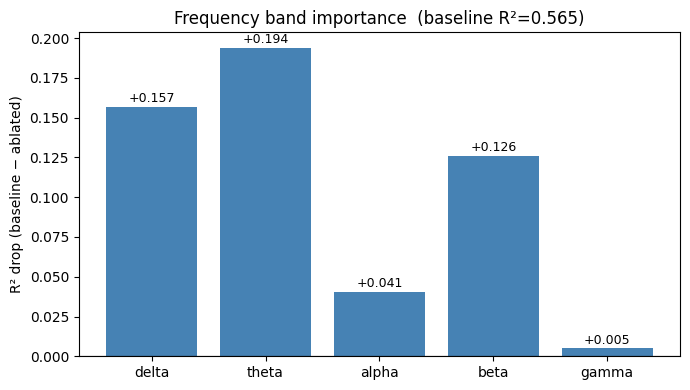

In [41]:
fig, ax = plt.subplots(figsize=(7, 4))
bands_sorted = list(BANDS.keys())
drops = [baseline_r2 - freq_results[b] for b in bands_sorted]

bars = ax.bar(bands_sorted, drops, color="steelblue")
ax.axhline(0, color="black", linewidth=0.8)
ax.set_ylabel("R² drop (baseline − ablated)")
ax.set_title(f"Frequency band importance  (baseline R²={baseline_r2:.3f})")
for bar, drop in zip(bars, drops):
    ax.text(bar.get_x() + bar.get_width()/2, drop + 0.001, f"{drop:+.3f}",
            ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.savefig("model_data/freq_band_importance.png", dpi=150)
plt.show()

## Experiment 2. Channel Importance

In [11]:
K_NEIGHBOURS = 3   # neighbours to mask alongside each target channel

# Build neighbour map from standard 10-20 montage positions
montage   = mne.channels.make_standard_montage("standard_1020")
positions = montage.get_positions()["ch_pos"]   # name -> (x, y, z)

# Only keep the 8 channels present in the data
ch_names  = CH_NAMES
coords    = np.array([positions[ch] for ch in ch_names])   # (8, 3)

def get_neighbours(ch_idx, k=K_NEIGHBOURS):
    dists = np.linalg.norm(coords - coords[ch_idx], axis=1)
    dists[ch_idx] = np.inf
    return list(np.argsort(dists)[:k])

neighbour_map = {i: [i] + get_neighbours(i) for i in range(len(ch_names))}

for i, ch in enumerate(ch_names):
    nbrs = [ch_names[j] for j in neighbour_map[i][1:]]
    print(f"  {ch}: mask [{ch}] + neighbours {nbrs}")

  C3: mask [C3] + neighbours ['P3', 'F3', 'Cz']
  C4: mask [C4] + neighbours ['P4', 'F4', 'T8']
  Cz: mask [Cz] + neighbours ['Pz', 'C3', 'Fz']
  F3: mask [F3] + neighbours ['Fz', 'F7', 'Fp1']
  F4: mask [F4] + neighbours ['Fz', 'F8', 'Fp2']
  F7: mask [F7] + neighbours ['F3', 'Fp1', 'T7']
  F8: mask [F8] + neighbours ['F4', 'Fp2', 'T8']
  Fp1: mask [Fp1] + neighbours ['F7', 'Fp2', 'F3']
  Fp2: mask [Fp2] + neighbours ['Fp1', 'F8', 'F4']
  Fz: mask [Fz] + neighbours ['F3', 'F4', 'Cz']
  O1: mask [O1] + neighbours ['P7', 'O2', 'P3']
  O2: mask [O2] + neighbours ['O1', 'P8', 'P4']
  P3: mask [P3] + neighbours ['Pz', 'P7', 'O1']
  P4: mask [P4] + neighbours ['Pz', 'P8', 'O2']
  P7: mask [P7] + neighbours ['T7', 'O1', 'P3']
  P8: mask [P8] + neighbours ['O2', 'T8', 'P4']
  Pz: mask [Pz] + neighbours ['P3', 'P4', 'Cz']
  T7: mask [T7] + neighbours ['P7', 'F7', 'C3']
  T8: mask [T8] + neighbours ['P8', 'F8', 'C4']


In [43]:
def channel_ablation_transform(ch_indices):
    """Return a transform that zeros out the given channel indices."""
    indices = list(ch_indices)
    def _apply(window):   # (n_ch, L)
        w = window.copy()
        w[indices, :] = 0.0
        return w
    return _apply

In [44]:
ch_results = {}
for i, ch in enumerate(ch_names):
    mask_idx = neighbour_map[i]
    r2 = run_inference(test_cache, test_targets,
                       transform=channel_ablation_transform(mask_idx))
    ch_results[ch] = r2
    masked = [ch_names[j] for j in mask_idx]
    print(f"  mask {masked}  →  R²={r2:.4f}  Δ={r2 - baseline_r2:+.4f}")

  mask ['C3', 'P3', 'F3', 'Cz']  →  R²=0.3590  Δ=-0.2056
  mask ['C4', 'P4', 'F4', 'T8']  →  R²=0.3757  Δ=-0.1889
  mask ['Cz', 'Pz', 'C3', 'Fz']  →  R²=-0.0056  Δ=-0.5703
  mask ['F3', 'Fz', 'F7', 'Fp1']  →  R²=0.3205  Δ=-0.2441
  mask ['F4', 'Fz', 'F8', 'Fp2']  →  R²=-0.7971  Δ=-1.3617
  mask ['F7', 'F3', 'Fp1', 'T7']  →  R²=0.3927  Δ=-0.1719
  mask ['F8', 'F4', 'Fp2', 'T8']  →  R²=-0.1285  Δ=-0.6931
  mask ['Fp1', 'F7', 'Fp2', 'F3']  →  R²=0.3770  Δ=-0.1877
  mask ['Fp2', 'Fp1', 'F8', 'F4']  →  R²=0.4585  Δ=-0.1062
  mask ['Fz', 'F3', 'F4', 'Cz']  →  R²=-0.0078  Δ=-0.5725
  mask ['O1', 'P7', 'O2', 'P3']  →  R²=0.4427  Δ=-0.1219
  mask ['O2', 'O1', 'P8', 'P4']  →  R²=0.3993  Δ=-0.1653
  mask ['P3', 'Pz', 'P7', 'O1']  →  R²=0.3422  Δ=-0.2225
  mask ['P4', 'Pz', 'P8', 'O2']  →  R²=0.3052  Δ=-0.2595
  mask ['P7', 'T7', 'O1', 'P3']  →  R²=0.4520  Δ=-0.1127
  mask ['P8', 'O2', 'T8', 'P4']  →  R²=0.3771  Δ=-0.1875
  mask ['Pz', 'P3', 'P4', 'Cz']  →  R²=0.3772  Δ=-0.1875
  mask ['T7', 'P7',

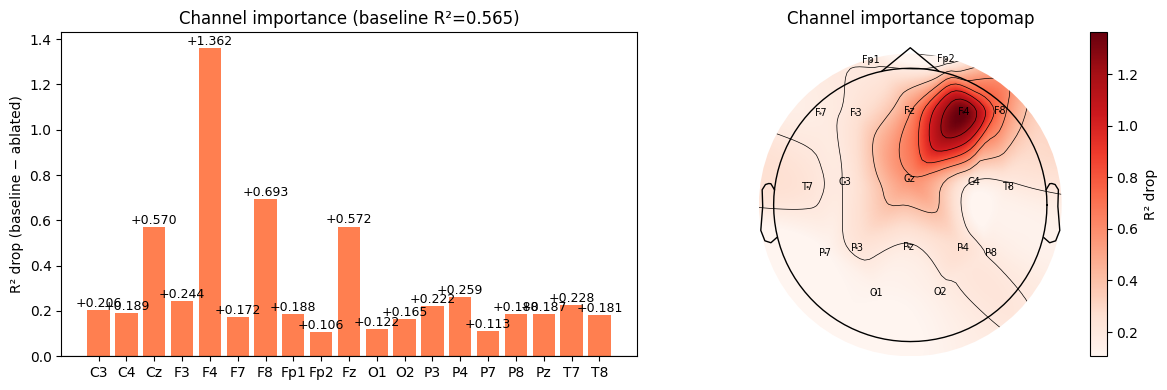

In [45]:
# Bar chart
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

drops_ch = [baseline_r2 - ch_results[ch] for ch in ch_names]
bars = axes[0].bar(ch_names, drops_ch, color="coral")
axes[0].axhline(0, color="black", linewidth=0.8)
axes[0].set_ylabel("R² drop (baseline − ablated)")
axes[0].set_title(f"Channel importance (baseline R²={baseline_r2:.3f})")
for bar, drop in zip(bars, drops_ch):
    axes[0].text(bar.get_x() + bar.get_width()/2, drop + 0.0005,
                 f"{drop:+.3f}", ha="center", va="bottom", fontsize=9)

# Topomap
importance = np.array([baseline_r2 - ch_results[ch] for ch in ch_names])
info = mne.create_info(ch_names, sfreq=SFREQ, ch_types="eeg")
info.set_montage("standard_1020")

im, _ = mne.viz.plot_topomap(
    importance, info, axes=axes[1], show=False,
    vlim=(importance.min(), importance.max()),
    cmap="Reds", sensors=True, names=ch_names,
)
plt.colorbar(im, ax=axes[1], label="R² drop")
axes[1].set_title("Channel importance topomap")

plt.tight_layout()
plt.savefig("model_data/channel_importance.png", dpi=150)
plt.show()

In [17]:
print(f"Baseline R²: {baseline_r2:.4f}\n")

print("Frequency band ablation:")
for band in BANDS:
    r2 = freq_results[band]
    print(f"  {band:6s}  R²={r2:.4f}  drop={baseline_r2 - r2:+.4f}")

print("\nChannel ablation:")
for ch in ch_names:
    r2 = ch_results[ch]
    print(f"  {ch:3s}  R²={r2:.4f}  drop={baseline_r2 - r2:+.4f}")

Baseline R²: 0.1846

Frequency band ablation:
  delta   R²=0.1312  drop=+0.0535
  theta   R²=0.0908  drop=+0.0938
  alpha   R²=0.1356  drop=+0.0490
  beta    R²=0.1679  drop=+0.0167
  gamma   R²=0.1794  drop=+0.0052

Channel ablation:
  C3   R²=0.0952  drop=+0.0894
  C4   R²=0.1296  drop=+0.0550
  Cz   R²=0.0887  drop=+0.0959
  F3   R²=0.1553  drop=+0.0293
  F4   R²=0.1490  drop=+0.0356
  F7   R²=0.1077  drop=+0.0769
  F8   R²=0.1588  drop=+0.0258
  Fp1  R²=0.1543  drop=+0.0303
  Fp2  R²=0.1763  drop=+0.0083
  Fz   R²=0.1264  drop=+0.0582
  O1   R²=-0.0376  drop=+0.2222
  O2   R²=-0.2605  drop=+0.4451
  P3   R²=0.0786  drop=+0.1061
  P4   R²=0.0264  drop=+0.1582
  P7   R²=-0.0154  drop=+0.2000
  P8   R²=-0.4588  drop=+0.6435
  Pz   R²=-0.1022  drop=+0.2868
  T7   R²=0.1213  drop=+0.0633
  T8   R²=0.0909  drop=+0.0937


## Experiment 3. T3/T4 (T7/T8) Power Spectra: Raw vs. ICA-Processed

In [10]:
from scipy.signal import welch

RAW_DIR = "model_data/orig_eeg_raw_19_channels"
ICA_DIR = "model_data/post_ica_19_channels_var_thresh"
NON_ICA_DIR = "model_data/non_ica_19_channels_thresh"
PSD_CHANNELS = ["T7", "T8"]   # T3/T4 in the old 10-20 nomenclature
EXAMPLE_SUBJECTS = list(test_subjects[60:70])

def load_channel_trace(parquet_dir, subject, channel):
    """Concatenate all segments for one channel into a single 1-D trace."""
    df = pd.read_parquet(Path(parquet_dir) / f"{subject}.parquet",
                          columns=["channel_name", "segment", "segment_index"])
    df = df[df["channel_name"] == channel].sort_values("segment_index")
    return np.concatenate([np.asarray(a, dtype=np.float32) for a in df["segment"]])

def compute_psd(trace, fs=SFREQ, seg_seconds=4):
    nperseg = min(len(trace), int(fs * seg_seconds))
    freqs, pxx = welch(trace, fs=fs, nperseg=nperseg)
    return freqs, pxx

print(f"Example subjects: {EXAMPLE_SUBJECTS}")

Example subjects: [np.str_('398835412'), np.str_('446391511'), np.str_('9869370'), np.str_('447217525'), np.str_('562702681'), np.str_('296764391'), np.str_('904406379'), np.str_('825997662'), np.str_('749779499'), np.str_('600992032')]


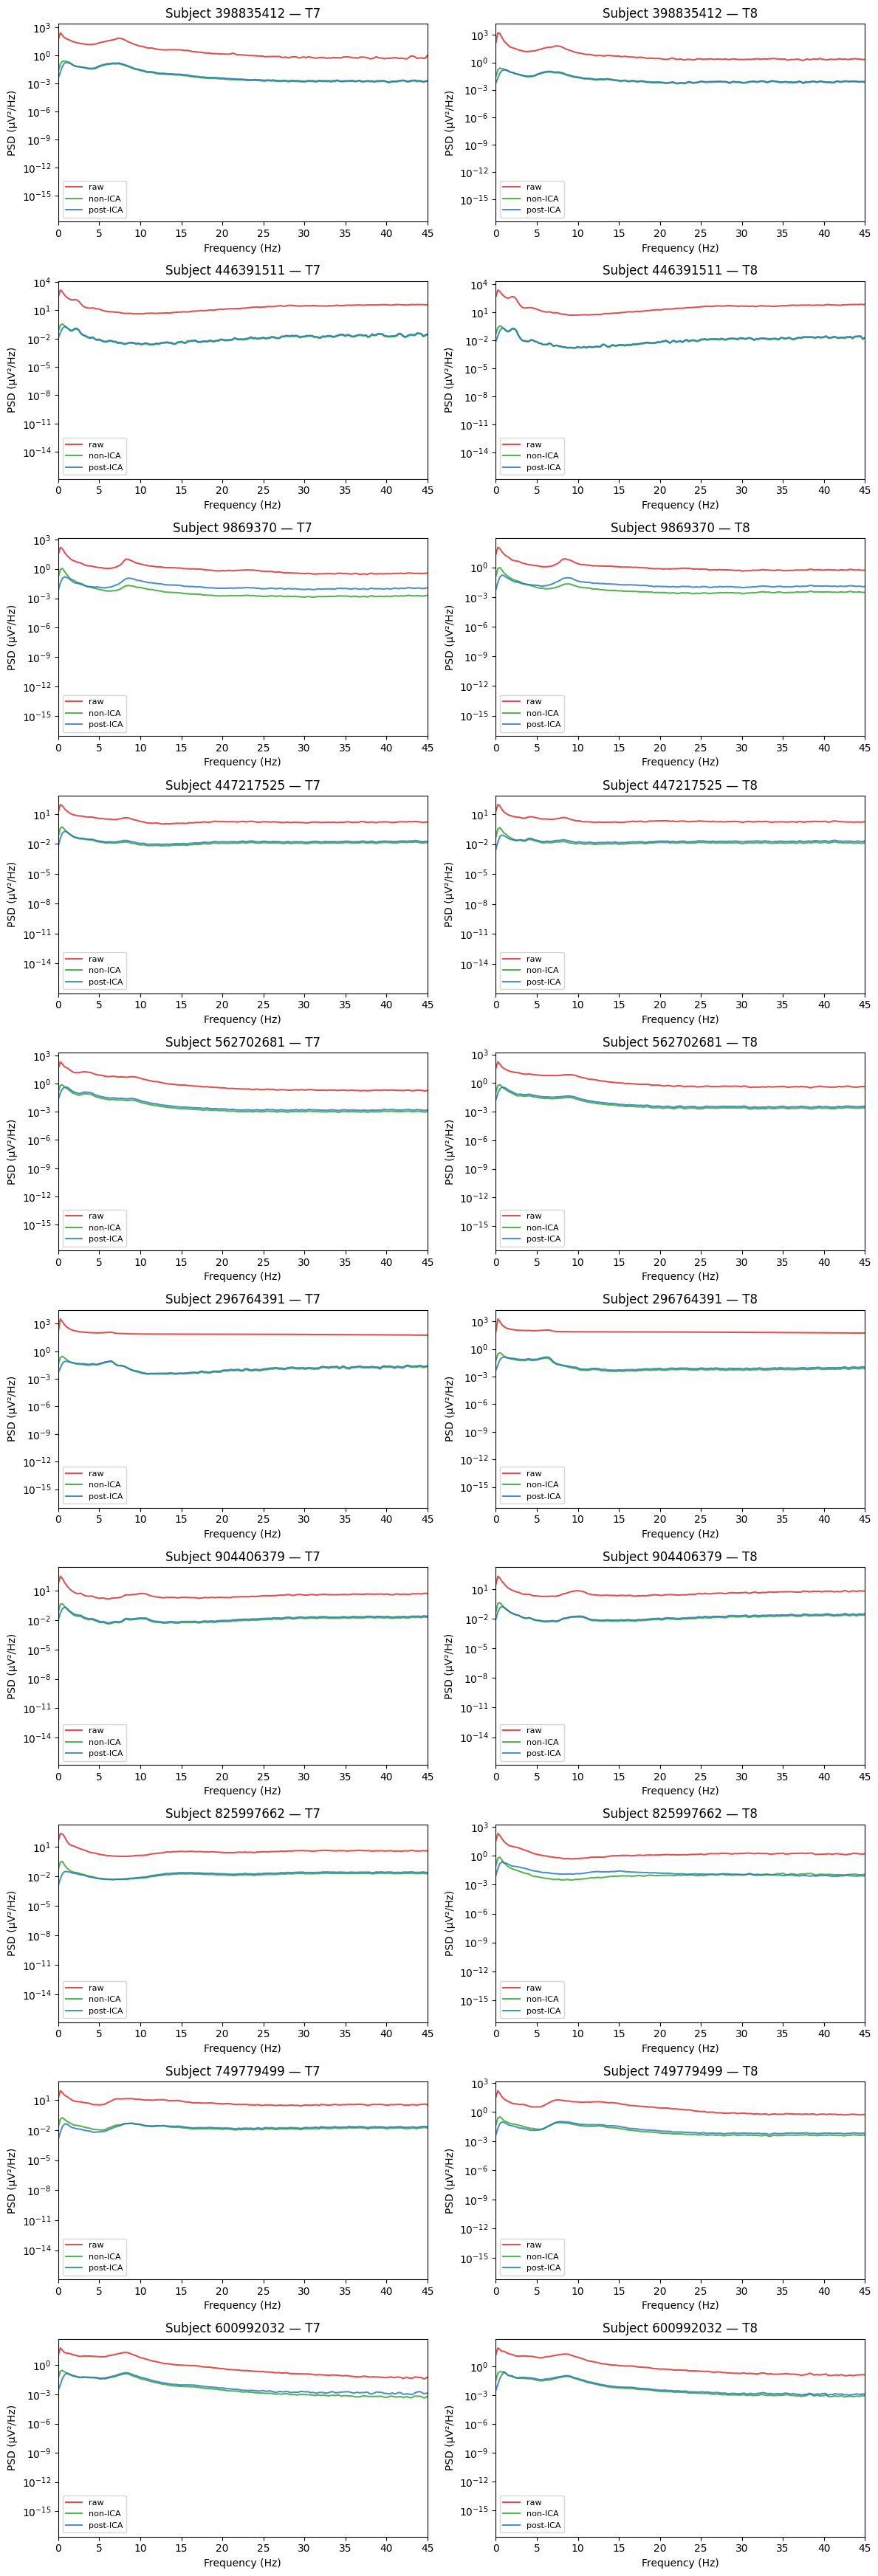

In [11]:
fig, axes = plt.subplots(len(EXAMPLE_SUBJECTS), len(PSD_CHANNELS),
                          figsize=(6 * len(PSD_CHANNELS), 3.5 * len(EXAMPLE_SUBJECTS)),
                          squeeze=False)

for row, subj in enumerate(EXAMPLE_SUBJECTS):
    for col, ch in enumerate(PSD_CHANNELS):
        ax = axes[row][col]
        raw_trace = load_channel_trace(RAW_DIR, subj, ch)
        ica_trace = load_channel_trace(ICA_DIR, subj, ch)
        non_ica_trace = load_channel_trace(NON_ICA_DIR, subj, ch)

        f_raw, p_raw = compute_psd(raw_trace)
        f_ica, p_ica = compute_psd(ica_trace)
        f_non_ica, p_non_ica = compute_psd(non_ica_trace)

        ax.semilogy(f_raw, p_raw, label="raw", color="tab:red", alpha=0.8)
        ax.semilogy(f_non_ica, p_non_ica, label="non-ICA", color="tab:green", alpha=0.8)
        ax.semilogy(f_ica, p_ica, label="post-ICA", color="tab:blue", alpha=0.8)
        ax.set_xlim(0, 45)
        ax.set_xlabel("Frequency (Hz)")
        ax.set_ylabel("PSD (µV²/Hz)")
        ax.set_title(f"Subject {subj} — {ch}")
        ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

## Experiment 4. Channel Importance — Retrained Ablation (HPC)

Unlike Experiment 2 above (which masks channels post-hoc on a single already-trained
checkpoint), this experiment retrains a full model from scratch per channel, with
that channel + its 3 nearest neighbours zero-masked throughout train, val, and
holdout (10-fold CV, top-3 ensemble per fold). It was run on Yale's Bouchet HPC,
once for the non-ICA (thresholded) 19-channel dataset and once for the
ICA-thresholded dataset, producing one `predictions_<channel>.parquet` per
channel per dataset (`fold_r2`, `mean_r2`, `global_r2` columns already computed
by `merge_cv_results.py`).

Because the model can compensate for a masked channel during training, expect
smaller R² drops here than in Experiment 2's post-hoc numbers — that's a real
methodological difference (retraining vs. post-hoc masking), not an inconsistency.

In [12]:
# ── Config: one entry per dataset ────────────────────────────────────────────
ABLATION_DATASETS = {
    "non_ica": {
        "label":         "Non-ICA (thresholded)",
        "baseline_path": "model_data/cv_results_stratified_thresh/predictions_1.parquet",
        "ablation_dir":  "model_data/channel_ablation_thresh_results",
    },
    "ica": {
        "label":         "ICA-thresholded",
        "baseline_path": "model_data/cv_results_stratified_ica_thresh/predictions_1.parquet",
        "ablation_dir":  "model_data/channel_ablation_thresh_ica_results",
    },
}

ABLATION_OUT_DIR = Path("model_data/channel_ablation_analysis")
ABLATION_OUT_DIR.mkdir(parents=True, exist_ok=True)


def baseline_metrics(path):
    """Recompute mean/global R2 from a raw (pre-fold_r2-column) predictions parquet."""
    df = pd.read_parquet(path)
    if "global_r2" in df.columns:
        return float(df["mean_r2"].iloc[0]), float(df["global_r2"].iloc[0])
    fold_r2 = {f: max(0.0, r2_score(g["true_pc1"], g["pred_pc1"]))
               for f, g in df.groupby("fold")}
    mean_r2 = float(np.mean(list(fold_r2.values())))
    global_r2 = float(r2_score(df["true_pc1"], df["pred_pc1"]))
    return mean_r2, global_r2


def load_ablation_results(ablation_dir):
    out = {}
    for ch in ch_names:
        p = Path(ablation_dir) / f"predictions_{ch}.parquet"
        df = pd.read_parquet(p)
        out[ch] = (float(df["mean_r2"].iloc[0]), float(df["global_r2"].iloc[0]))
    return out

In [13]:
# ── Compute baseline + ablated R2, and per-channel drops, for both datasets ──
ablation_results_by_dataset = {}

for key, cfg in ABLATION_DATASETS.items():
    baseline_mean, baseline_global = baseline_metrics(cfg["baseline_path"])
    ablation = load_ablation_results(cfg["ablation_dir"])

    print(f"=== {cfg['label']} ===")
    print(f"Baseline: mean_r2={baseline_mean:.4f}  global_r2={baseline_global:.4f}\n")

    rows = []
    for ch in ch_names:
        ab_mean, ab_global = ablation[ch]
        drop_mean = baseline_mean - ab_mean
        drop_global = baseline_global - ab_global
        print(f"  {ch:3s}  ablated mean_r2={ab_mean:.4f} (drop {drop_mean:+.4f})   "
              f"global_r2={ab_global:.4f} (drop {drop_global:+.4f})")
        rows.append({
            "dataset": key, "channel": ch,
            "baseline_mean_r2": baseline_mean, "baseline_global_r2": baseline_global,
            "ablated_mean_r2": ab_mean, "ablated_global_r2": ab_global,
            "drop_mean_r2": drop_mean, "drop_global_r2": drop_global,
        })

    df = pd.DataFrame(rows)
    ablation_results_by_dataset[key] = df
    print(f"\nMost -> least important, by global R2 drop:")
    print(df.sort_values("drop_global_r2", ascending=False)[["channel", "drop_global_r2", "drop_mean_r2"]].to_string(index=False))
    print()

ablation_summary = pd.concat(ablation_results_by_dataset.values(), ignore_index=True)
summary_path = ABLATION_OUT_DIR / "channel_importance_summary.parquet"
ablation_summary.to_parquet(summary_path, index=False)
print(f"Saved combined summary -> {summary_path}")

=== Non-ICA (thresholded) ===
Baseline: mean_r2=0.4479  global_r2=0.4257

  C3   ablated mean_r2=0.4432 (drop +0.0048)   global_r2=0.4310 (drop -0.0053)
  C4   ablated mean_r2=0.4591 (drop -0.0112)   global_r2=0.4475 (drop -0.0218)
  Cz   ablated mean_r2=0.4355 (drop +0.0124)   global_r2=0.4119 (drop +0.0138)
  F3   ablated mean_r2=0.4555 (drop -0.0076)   global_r2=0.4230 (drop +0.0027)
  F4   ablated mean_r2=0.4184 (drop +0.0295)   global_r2=0.3975 (drop +0.0281)
  F7   ablated mean_r2=0.4683 (drop -0.0204)   global_r2=0.4359 (drop -0.0102)
  F8   ablated mean_r2=0.4085 (drop +0.0394)   global_r2=0.3912 (drop +0.0344)
  Fp1  ablated mean_r2=0.4574 (drop -0.0095)   global_r2=0.4196 (drop +0.0061)
  Fp2  ablated mean_r2=0.4257 (drop +0.0222)   global_r2=0.4096 (drop +0.0161)
  Fz   ablated mean_r2=0.4005 (drop +0.0474)   global_r2=0.3702 (drop +0.0555)
  O1   ablated mean_r2=0.4561 (drop -0.0082)   global_r2=0.4349 (drop -0.0093)
  O2   ablated mean_r2=0.4679 (drop -0.0200)   global_r2=

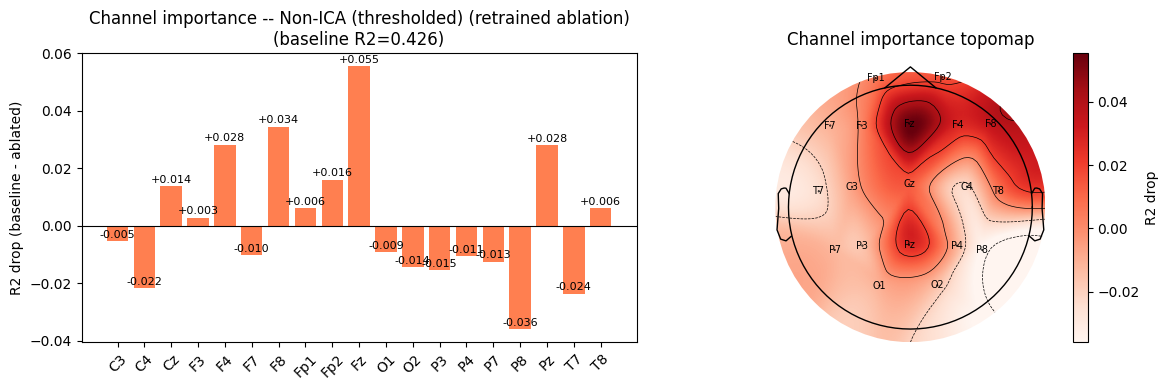

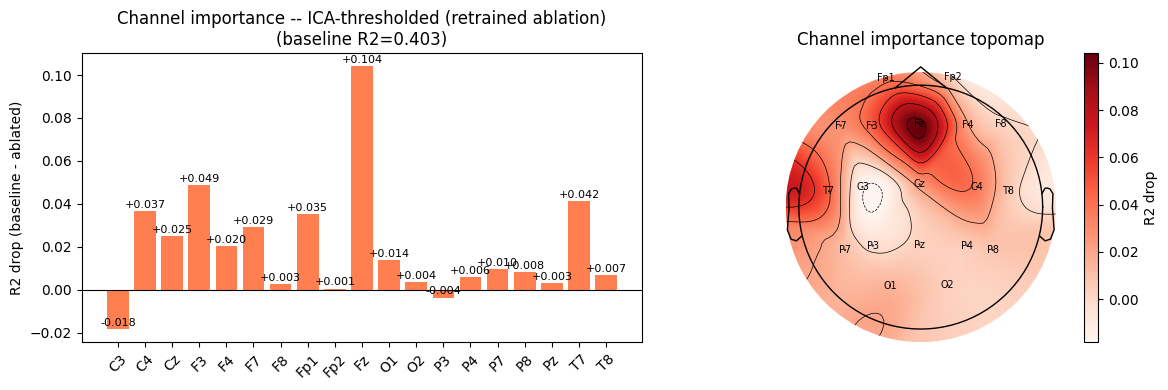

In [16]:
# ── Graphs 1 & 2: per-dataset bar chart + topomap ────────────────────────────
def plot_channel_importance(names, drops, baseline_r2, title, out_png):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    bars = axes[0].bar(names, drops, color="coral")
    axes[0].axhline(0, color="black", linewidth=0.8)
    axes[0].set_ylabel("R2 drop (baseline - ablated)")
    axes[0].set_title(f"{title}\n(baseline R2={baseline_r2:.3f})")
    axes[0].tick_params(axis="x", rotation=45)
    for bar, drop in zip(bars, drops):
        axes[0].text(bar.get_x() + bar.get_width() / 2, drop + 0.0005,
                     f"{drop:+.3f}", ha="center", va="bottom", fontsize=8)

    montage = mne.channels.make_standard_montage("standard_1020")
    info = mne.create_info(names, sfreq=SFREQ, ch_types="eeg")
    info.set_montage(montage)

    importance = np.array(drops)
    vmin, vmax = importance.min(), importance.max()
    if vmin == vmax:
        vmin, vmax = vmin - 0.01, vmax + 0.01
    im, _ = mne.viz.plot_topomap(
        importance, info, axes=axes[1], show=False,
        vlim=(vmin, vmax), cmap="Reds", sensors=True, names=names,
    )
    plt.colorbar(im, ax=axes[1], label="R2 drop")
    axes[1].set_title("Channel importance topomap")

    plt.tight_layout()
    plt.savefig(out_png, dpi=150)
    plt.show()


for key, cfg in ABLATION_DATASETS.items():
    df = ablation_results_by_dataset[key]
    drops = [df.loc[df["channel"] == ch, "drop_global_r2"].iloc[0] for ch in ch_names]
    baseline_global = df["baseline_global_r2"].iloc[0]
    plot_channel_importance(
        ch_names, drops, baseline_global,
        f"Channel importance -- {cfg['label']} (retrained ablation)",
        ABLATION_OUT_DIR / f"channel_importance_{key}.png",
    )

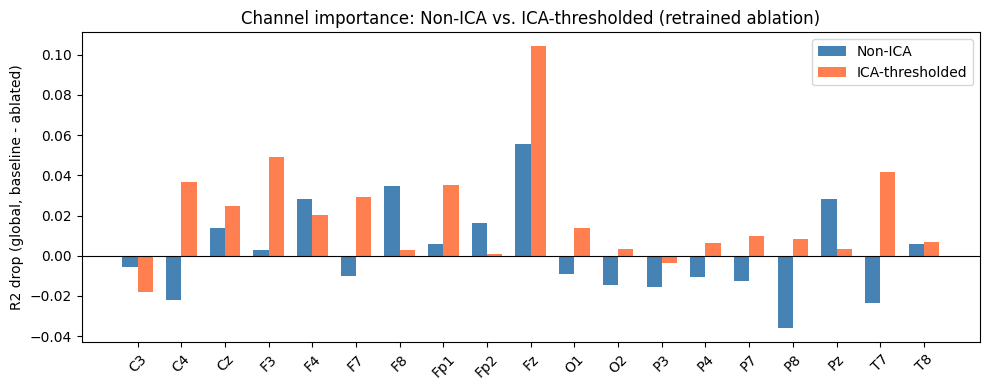

Saved model_data/channel_ablation_analysis/channel_importance_comparison.png


In [17]:
# ── Graph 3: Non-ICA vs. ICA-thresholded comparison ──────────────────────────
pivot = ablation_summary.pivot(index="channel", columns="dataset", values="drop_global_r2").loc[ch_names]

fig, ax = plt.subplots(figsize=(10, 4))
x = np.arange(len(ch_names))
width = 0.35
ax.bar(x - width/2, pivot["non_ica"], width, label="Non-ICA", color="steelblue")
ax.bar(x + width/2, pivot["ica"], width, label="ICA-thresholded", color="coral")
ax.axhline(0, color="black", linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels(ch_names, rotation=45)
ax.set_ylabel("R2 drop (global, baseline - ablated)")
ax.set_title("Channel importance: Non-ICA vs. ICA-thresholded (retrained ablation)")
ax.legend()
plt.tight_layout()
compare_png = ABLATION_OUT_DIR / "channel_importance_comparison.png"
plt.savefig(compare_png, dpi=150)
plt.show()
print(f"Saved {compare_png}")

## Experiment 5. Frequency Band Importance — Retrained Ablation (HPC)

Same retraining philosophy as Experiment 4, but ablating a frequency band instead of a
spatial channel: each band (delta, theta, alpha, beta, gamma) is bandstop-filtered out of
*every* channel (4th-order zero-phase Butterworth) throughout train, val, and holdout, then
a full model is retrained from scratch (10-fold CV, top-3 ensemble per fold). Run on Yale's
Bouchet HPC via `run_band_ablation.py`, for PC1, PC5, and PC8 on the non-ICA (thresholded)
dataset, producing one `predictions_<band>.parquet` per band per PC.

As with Experiment 4 vs. Experiment 2, expect smaller R² drops here than in Experiment 1's
post-hoc numbers, since the model can partially compensate for a missing band during training.

In [ ]:
# ── Config: one entry per PC (non-ICA only) ──────────────────────────────────
BAND_ORDER = ["delta", "theta", "alpha", "beta", "gamma"]

BAND_ABLATION_DATASETS = {
    "pc1": {
        "label":         "PC1",
        "baseline_path": "model_data/cv_results_stratified_thresh/predictions_1.parquet",
        "ablation_dir":  "model_data/band_ablation_thresh_pc1_results",
    },
    "pc5": {
        "label":         "PC5",
        "baseline_path": "model_data/cv_results_stratified_thresh/predictions_5.parquet",
        "ablation_dir":  "model_data/band_ablation_thresh_pc5_results",
    },
    "pc8": {
        "label":         "PC8",
        "baseline_path": "model_data/cv_results_stratified_thresh/predictions_8.parquet",
        "ablation_dir":  "model_data/band_ablation_thresh_pc8_results",
    },
}

BAND_OUT_DIR = Path("model_data/band_ablation_analysis")
BAND_OUT_DIR.mkdir(parents=True, exist_ok=True)

# baseline_metrics() reused from Experiment 4's config cell above.

def load_band_ablation_results(ablation_dir):
    out = {}
    for band in BAND_ORDER:
        p = Path(ablation_dir) / f"predictions_{band}.parquet"
        df = pd.read_parquet(p)
        out[band] = (float(df["mean_r2"].iloc[0]), float(df["global_r2"].iloc[0]))
    return out

In [ ]:
# ── Compute baseline + ablated R2, and per-band drops, for PC1/PC5/PC8 ───────
band_results_by_pc = {}

for key, cfg in BAND_ABLATION_DATASETS.items():
    baseline_mean, baseline_global = baseline_metrics(cfg["baseline_path"])
    ablation = load_band_ablation_results(cfg["ablation_dir"])

    print(f"=== {cfg['label']} ===")
    print(f"Baseline: mean_r2={baseline_mean:.4f}  global_r2={baseline_global:.4f}\n")

    rows = []
    for band in BAND_ORDER:
        ab_mean, ab_global = ablation[band]
        drop_mean = baseline_mean - ab_mean
        drop_global = baseline_global - ab_global
        print(f"  {band:6s}  ablated mean_r2={ab_mean:.4f} (drop {drop_mean:+.4f})   "
              f"global_r2={ab_global:.4f} (drop {drop_global:+.4f})")
        rows.append({
            "pc": key, "band": band,
            "baseline_mean_r2": baseline_mean, "baseline_global_r2": baseline_global,
            "ablated_mean_r2": ab_mean, "ablated_global_r2": ab_global,
            "drop_mean_r2": drop_mean, "drop_global_r2": drop_global,
        })

    df = pd.DataFrame(rows)
    band_results_by_pc[key] = df
    print(f"\nMost -> least important, by global R2 drop:")
    print(df.sort_values("drop_global_r2", ascending=False)[["band", "drop_global_r2", "drop_mean_r2"]].to_string(index=False))
    print()

band_ablation_summary = pd.concat(band_results_by_pc.values(), ignore_index=True)
band_summary_path = BAND_OUT_DIR / "band_importance_summary.parquet"
band_ablation_summary.to_parquet(band_summary_path, index=False)
print(f"Saved combined summary -> {band_summary_path}")

In [ ]:
# ── Graph 1: per-PC bar chart of band importance ─────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

for ax, (key, cfg) in zip(axes, BAND_ABLATION_DATASETS.items()):
    df = band_results_by_pc[key]
    drops = [df.loc[df["band"] == b, "drop_global_r2"].iloc[0] for b in BAND_ORDER]
    baseline_global = df["baseline_global_r2"].iloc[0]

    bars = ax.bar(BAND_ORDER, drops, color="mediumseagreen")
    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_title(f"{cfg['label']}\n(baseline R2={baseline_global:.3f})")
    ax.set_ylabel("R2 drop (baseline - ablated)")
    ax.tick_params(axis="x", rotation=45)
    for bar, drop in zip(bars, drops):
        ax.text(bar.get_x() + bar.get_width() / 2, drop + 0.0005,
                f"{drop:+.3f}", ha="center", va="bottom", fontsize=8)

fig.suptitle("Frequency band importance -- non-ICA (retrained ablation)")
plt.tight_layout()
band_bar_png = BAND_OUT_DIR / "band_importance_by_pc.png"
plt.savefig(band_bar_png, dpi=150)
plt.show()
print(f"Saved {band_bar_png}")

In [ ]:
# ── Graph 2: PC1 vs. PC5 vs. PC8 comparison, grouped by band ─────────────────
pivot_band = band_ablation_summary.pivot(index="band", columns="pc", values="drop_global_r2").loc[BAND_ORDER]

fig, ax = plt.subplots(figsize=(9, 4))
x = np.arange(len(BAND_ORDER))
width = 0.25
colors = {"pc1": "steelblue", "pc5": "coral", "pc8": "goldenrod"}
for i, key in enumerate(BAND_ABLATION_DATASETS.keys()):
    ax.bar(x + (i - 1) * width, pivot_band[key], width,
          label=BAND_ABLATION_DATASETS[key]["label"], color=colors[key])
ax.axhline(0, color="black", linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels(BAND_ORDER, rotation=45)
ax.set_ylabel("R2 drop (global, baseline - ablated)")
ax.set_title("Frequency band importance: PC1 vs. PC5 vs. PC8 (non-ICA, retrained ablation)")
ax.legend()
plt.tight_layout()
band_compare_png = BAND_OUT_DIR / "band_importance_comparison.png"
plt.savefig(band_compare_png, dpi=150)
plt.show()
print(f"Saved {band_compare_png}")